LOADING RESULTS

✓ Loaded 24 rows from C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\Code\CulturalES_WildfireRx\outputs\did_results_firetype.csv

States: ['CO' 'CA']
Fire types: ['wildfire' 'prescribed']

CREATING FIGURE: OVERALL EFFECTS

✓ Saved figures to: C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\Code\CulturalES_WildfireRx\outputs\figures
  • Overall_Effects.png (600 DPI)
  • Overall_Effects.pdf (vector)
  • Overall_Effects_HighRes.png (1200 DPI)


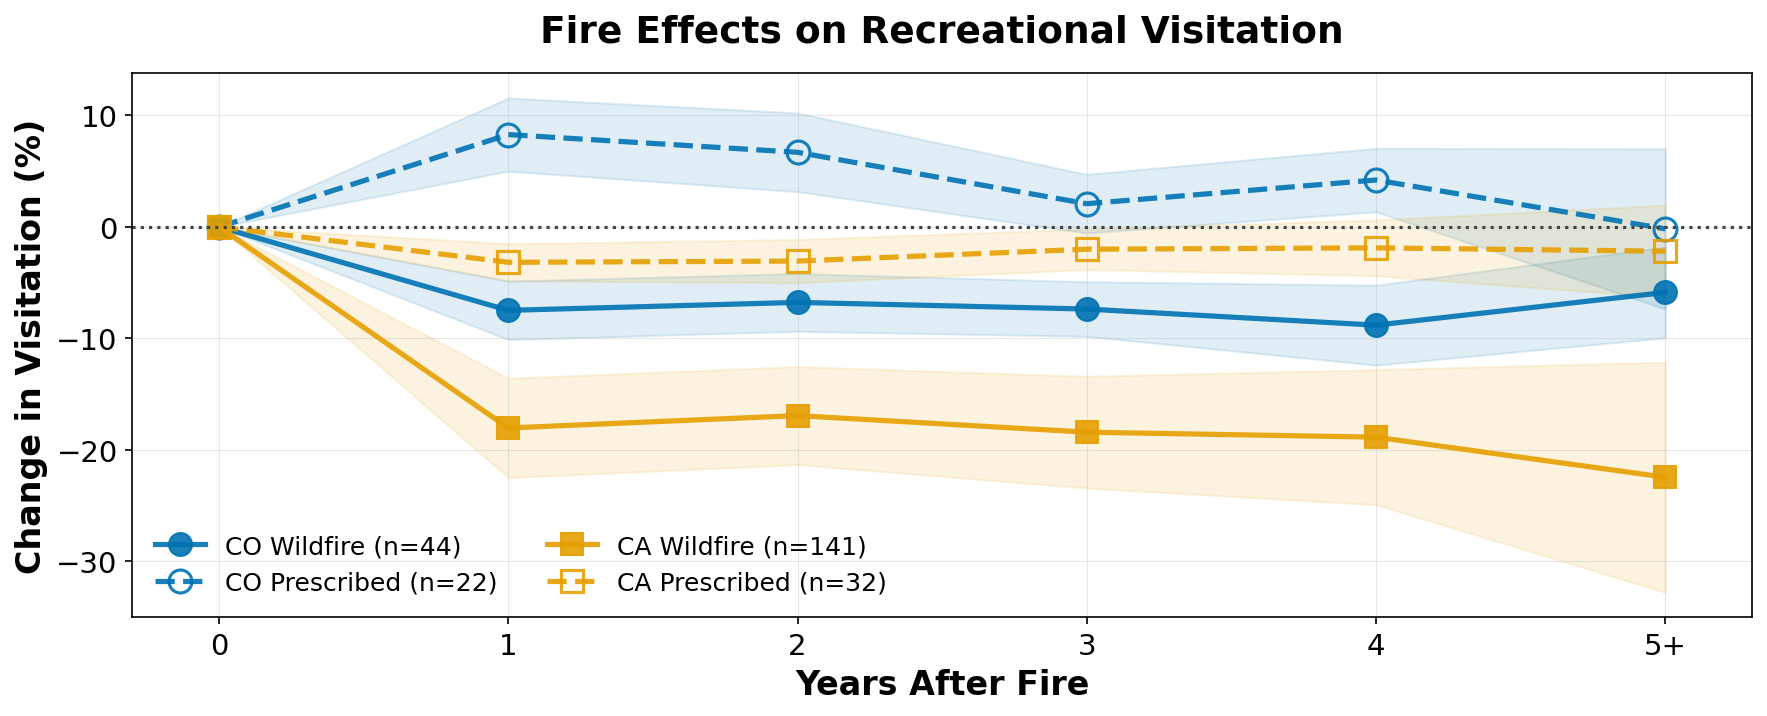


DONE

SUMMARY: YEAR 1 EFFECTS

Colorado:
  Wildfire    :   -7.5% (95% CI:  -10.1% to   -4.9%)
                 n=44 treated, 40 control
  Prescribed  :   +8.3% (95% CI:   +5.0% to  +11.6%)
                 n=22 treated, 22 control

California:
  Wildfire    :  -18.0% (95% CI:  -22.5% to  -13.6%)
                 n=141 treated, 142 control
  Prescribed  :   -3.2% (95% CI:   -4.8% to   -1.5%)
                 n=32 treated, 35 control


In [5]:
"""
Plot Overall Fire Effects
==========================
Loads DiD results and creates publication-ready figure of overall effects.

Displays in notebook and saves to files.
"""

import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from pathlib import Path
import logging

# Suppress any warnings
warnings.filterwarnings('ignore')
import warnings
import logging

# Suppress fontTools logging messages (from PDF creation)
logging.getLogger('fontTools').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
import logging

# Suppress font subsetting messages
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# ============================================================
# SETTINGS
# ============================================================

# Resolve directory of this file (works in .py; falls back to CWD in notebooks)
try:
    HERE = Path(__file__).resolve().parent
except NameError:
    HERE = Path.cwd()

# Where to load results from (relative to this notebook/script)
RESULTS_CSV = (HERE / "../outputs/did_results_firetype.csv").resolve()

# Where to save figures (relative to this notebook/script)
OUTPUT_DIR = (HERE / "../outputs/figures").resolve()

# ============================================================
# FIGURE SETTINGS
# ============================================================

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "figure.dpi": 150,
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# Colorblind-friendly: Blue for CO, Orange for CA
state_colors = {
    'CO': '#0072B2',  # Blue
    'CA': '#E69F00',  # Orange
}

state_markers = {
    'CO': 'o',  # Circle
    'CA': 's',  # Square
}

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING RESULTS")
print("=" * 60)

df = pd.read_csv(RESULTS_CSV)
print(f"\n✓ Loaded {len(df)} rows from {RESULTS_CSV}")
print(f"\nStates: {df['state'].unique()}")
print(f"Fire types: {df['fire_type'].unique()}")

# ============================================================
# CREATE FIGURE
# ============================================================

print("\n" + "=" * 60)
print("CREATING FIGURE: OVERALL EFFECTS")
print("=" * 60)

fig, ax = plt.subplots(figsize=(12, 5))

for state in ['CO', 'CA']:
    for ft in ['wildfire', 'prescribed']:
        
        # Filter data
        data = df[(df['state'] == state) & (df['fire_type'] == ft)]
        
        if len(data) == 0:
            continue
        
        # Sort by year
        data = data.sort_values('year')
        
        years = data['year'].values
        effects = data['effect_pct'].values
        ci_lower = data['ci_lower'].values
        ci_upper = data['ci_upper'].values
        n_treated = data['n_treated'].iloc[0] if len(data) > 0 else 0
        
        # Styling
        color = state_colors[state]
        marker = state_markers[state]
        linestyle = '-' if ft == 'wildfire' else '--'
        fillstyle = 'full' if ft == 'wildfire' else 'none'
        markeredgewidth = 1.5 if ft == 'prescribed' else 1.0
        
        label = f"{state} {ft.capitalize()} (n={n_treated})"
        
        # Plot
        ax.plot(years, effects, marker=marker, markersize=11, linewidth=2.5,
                linestyle=linestyle, color=color, label=label, alpha=0.9,
                fillstyle=fillstyle, markeredgewidth=markeredgewidth, 
                markeredgecolor=color)
        ax.fill_between(years, ci_lower, ci_upper, alpha=0.12, color=color)

# Formatting
ax.axhline(0, color='#424242', linestyle=':', linewidth=1.5)
ax.set_xlabel('Years After Fire', fontsize=16, fontweight='bold')
ax.set_ylabel('Change in Visitation (%)', fontsize=16, fontweight='bold')
ax.set_title('Fire Effects on Recreational Visitation', 
             fontsize=18, fontweight='bold', pad=15)

ax.set_xticks(range(6))
ax.set_xticklabels(['0', '1', '2', '3', '4', '5+'], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

ax.legend(loc='lower left', fontsize=12, framealpha=0, ncol=2)
ax.grid(alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim(-0.3, 5.3)

plt.tight_layout()

# Save high-resolution figures
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Standard publication quality (600 DPI)
fig.savefig(OUTPUT_DIR / 'Overall_Effects.png', 
            bbox_inches='tight', dpi=600)
fig.savefig(OUTPUT_DIR / 'Overall_Effects.pdf', 
            bbox_inches='tight')

# Ultra high-resolution for printing/posters (1200 DPI)
fig.savefig(OUTPUT_DIR / 'Overall_Effects_HighRes.png', 
            bbox_inches='tight', dpi=1200)

print("\n✓ Saved figures to:", OUTPUT_DIR)
print("  • Overall_Effects.png (600 DPI)")
print("  • Overall_Effects.pdf (vector)")
print("  • Overall_Effects_HighRes.png (1200 DPI)")

# Display in notebook
plt.show()

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

# ============================================================
# PRINT SUMMARY STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY: YEAR 1 EFFECTS")
print("=" * 60)

year1 = df[df['year'] == 1]

for state in ['CO', 'CA']:
    state_name = 'Colorado' if state == 'CO' else 'California'
    print(f"\n{state_name}:")
    
    for ft in ['wildfire', 'prescribed']:
        row = year1[(year1['state'] == state) & (year1['fire_type'] == ft)]
        
        if len(row) > 0:
            row = row.iloc[0]
            print(f"  {ft.capitalize():12s}: {row['effect_pct']:+6.1f}% "
                  f"(95% CI: {row['ci_lower']:+6.1f}% to {row['ci_upper']:+6.1f}%)")
            print(f"                 n={row['n_treated']} treated, {row['n_control']} control")